# Cálculo Numérico - EP 1 - Zeros de Funções

## Item a:
Resolva numericamente a equação $x^{3/4}-\text{cos}(x^2)=0$ pelo método da bissecção.

Primeiro, defino a função iterativa de bissecção:

In [108]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

In [109]:
def bissec(func,interval,erro): #Definida como em pg. 5 das notas de aula
    x1,x2 = interval #Define o intervalo inicial
    xmlist = [] #Guardará os valores em cada iteração
    while abs(x1-x2) > erro:
        xm = (x1+x2)/2
        xmlist.append(xm)
        if np.sign(func(x1)) == np.sign(func(xm)):
            x1 = xm
        else: 
            x2 = xm
    return xmlist #Preferi retornar a lista ao invés do valor final para fazer tabelas mais apresentáveis no Pandas e também plots.
        

Agora, testo com uma função cuja raiz seja conhecida: $\text{sin}(x)$

In [110]:
sin = lambda x: np.sin(x) #Função seno

sol = bissec(sin,[-1,4],1e-5) #Teste da função seno

data = {"m":[m for m in range(len(sol))],"x_m":sol,"f(x_m)":np.sin(sol)} #Dicionário para a tabela

pd.DataFrame(data,index=None) #Tabela do teste da função seno

,m,x_m,f(x_m)
0,0,1.500000,0.997495
1,1,0.250000,0.247404
2,2,-0.375000,-0.366273
3,3,-0.062500,-0.062459
4,4,0.093750,0.093613
5,5,0.015625,0.015624
6,6,-0.023438,-0.023435
7,7,-0.003906,-0.003906
8,8,0.005859,0.005859
9,9,0.000977,0.000977


Pode ser útil ter um gráfico para visualizar a convergência da implementação:

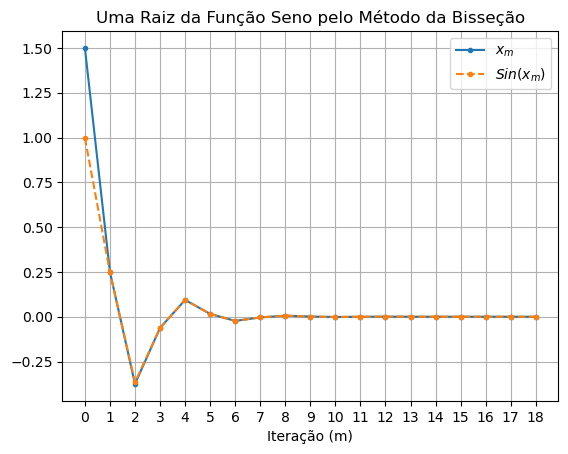

In [111]:
plt.plot(data['x_m'],'.-',label="$x_m$") #Plot das bisseções
plt.plot(data['f(x_m)'],'.--', label="$Sin(x_m)$") #Plot da função seno 
#---------- Estética ----------
plt.legend()
plt.title("Uma Raiz da Função Seno pelo Método da Bisseção")
plt.xlabel("Iteração (m)")
plt.xticks(data['m'])
plt.grid()

Ou seja, o código parece indicar que $0$ é uma raíz de $\text{Sin}(x)$, o que era o esperado.

Prossigo, então, com a função em questão.

In [112]:
func = lambda x: x**(3./4.) - np.cos(x**2) #Função do problema

sol = bissec(func,[-5,5],1e-6) #Solução pelo meu algoritmo de bisseção

funcsol = [func(i) for i in sol] #Aplica a função do problema aos valores de solução

data = {"x_m":sol,"f(x_m)":funcsol} #Dicionário para a tabela

pd.DataFrame(data,index=None) #Tabela da convergência da função do problema

,x_m,f(x_m)
0,0.000000,-1.000000e+00
1,2.500000,9.887274e-01
2,1.250000,1.173881e+00
3,0.625000,-2.217446e-01
4,0.937500,3.147551e-01
5,0.781250,1.153717e-02
6,0.703125,-1.124143e-01
7,0.742188,-5.246106e-02
8,0.761719,-2.099097e-02
9,0.771484,-4.862005e-03


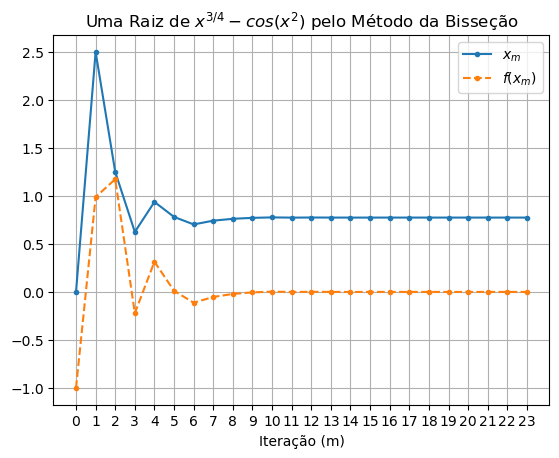

In [113]:
plt.plot(data['x_m'],'.-',label="$x_m$") #Plot das bisseções
plt.plot(data['f(x_m)'],'.--', label='$f(x_m)$') #Plot da função em questão
#---------- Estética ----------
plt.legend()
plt.title("Uma Raiz de $x^{3/4}-cos(x^2)$ pelo Método da Bisseção")
plt.xlabel("Iteração (m)")
plt.xticks(range(len(sol)))
plt.grid()

## Item b: Resolva o problema anterior com o método de Newton-Raphson

Novamente, defino primeiro um algoritmo para o método NR

In [114]:
def NR(func,deriv,x0,err): #Colocar a derivada aqui, como um argumento, me incomoda muito, mas quero evitar uma derivação numérica, para distinguir entre NR e o método das Secantes.
    xn = x0 
    xlist = [x0]
    while abs(func(xn)) > err: #Aqui começa a iteração, de fato.
        xn = xn - func(xn)/deriv(xn) #x_(n+1) = x_n - f(x_n)/f'(x_n)
        xlist.append(xn)
    return xlist

Como já temos um método para o cômputo da raíz de $f(x) = x^{3/4}-\text{cos}(x^2)$, podemos utilizá-lo como critério de comparação.

Ademais $D_xf(x) = \frac{3}{4}x^{-\frac{1}{4}}+2x\text{Sin}(x^2)$

In [115]:
func = lambda x: x**(3./4.) - np.cos(x**2) #Função do problema

deriv = lambda x: 3./4.*x**(-1./4.) + 2*x*np.sin(x**2) #Derivada da função do problema

sol = NR(func,deriv,1.25,1e-6) #Solução pelo método de Newton-Raphson. Tomei x0 = 1.25, pois, pelo método da bisseção, está próximo de m=2, que parece estar convergindo.

funcsol = [i for i in map(func,sol)] #Aplica a função do problema aos valores de solução

data = {"x_m":sol,"f(x_m)":funcsol} #Dicionário para a tabela

pd.DataFrame(data) #Tabela da convergência da função do problema

,x_m,f(x_m)
0,1.250000,1.173881e+00
1,0.884216,2.022209e-01
2,0.784079,1.633940e-02
3,0.774476,1.332247e-04
4,0.774397,9.030932e-09


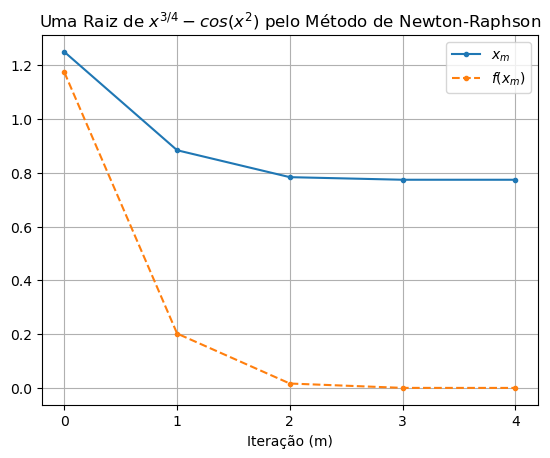

In [116]:
plt.plot(data['x_m'],'.-',label="$x_m$") #Plot das bisseções
plt.plot(data['f(x_m)'],'.--', label='$f(x_m)$') #Plot da função em questão
#---------- Estética ----------
plt.legend()
plt.title("Uma Raiz de $x^{3/4}-cos(x^2)$ pelo Método de Newton-Raphson")
plt.xlabel("Iteração (m)")
plt.xticks(range(len(sol)))
plt.grid()

## Item c

Vou começar definindo as constantes apropriadas para facilitar os códigos e garantir a dimensionalidade correta no problema.

In [117]:
#Constantes ---------------------
V0 = 1.38 * 10 ** 3 #eV
r0 = 0.328 # Angstrom
K = 14.4 # eV*Angstrom

Agora, defino $V(r)$, $F(r)$ e o método das secantes:

In [118]:
def V(r):
    return (-K/r + V0*np.exp(-r/r0))

def F(r):
    return (- K/r**2 + V0/r0*np.exp(-r/r0))

def secantes(func,x0,x1,err):
    xn = x1
    xlist = [x0,x1]
    while abs(func(xn)) > err: #Aqui começa a iteração, de fato.
        xnmenos1 = xlist[-2] #x_(n-1) o nome da variável ficou feio, mas é a vida.
        xn = xn - func(xn)*(xn - xnmenos1)/(func(xn)-func(xnmenos1)) #x_(n+1) = x_n - f(x_n)(x_n - x_{n-1}) / (f(x_n) + f(x_{n-1}))
        xlist.append(xn)
    return xlist
    

Agora, os plots de $F(r)$ e $V(r)$

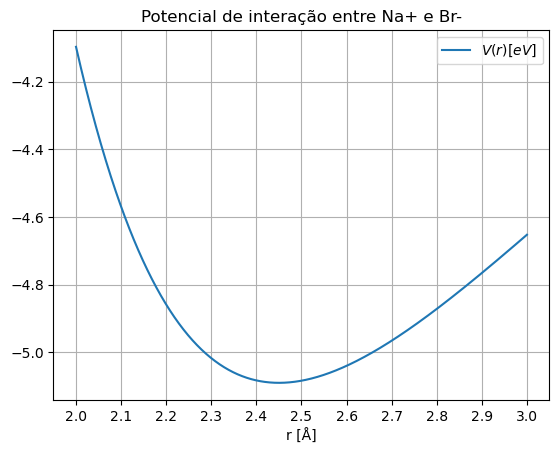

In [126]:
xdata = [i for i in np.linspace(2.0,3.0,1000)] #Gera os valores de x
Vdata = [V(i) for i in xdata] #Gera os valores de V(x)
Fdata = [F(i) for i in xdata] #Gera os valores de F(x)
plt.plot(xdata,Vdata,label="$V(r) [eV]$") #Plot de V(r)
#---------- Estética ----------
plt.legend()
plt.title("Potencial de interação entre Na+ e Br-")
plt.xlabel("r [Å]")
plt.xticks(np.linspace(2,3,11))
plt.grid()

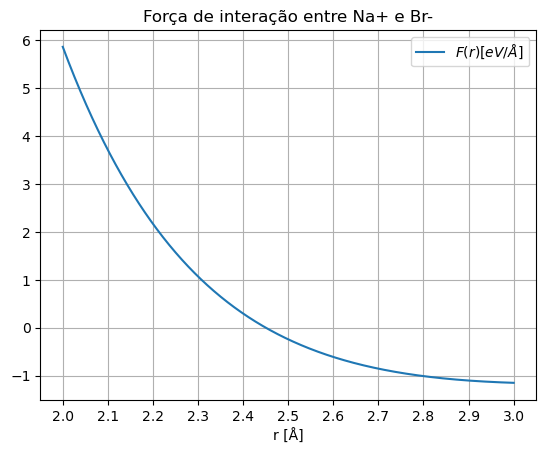

In [125]:
xdata = [i for i in np.linspace(2.0,3.0,1000)] #Gera os valores de x
Fdata = [F(i) for i in xdata] #Gera os valores de F(x)
plt.plot(xdata,Fdata,label="$F(r) [eV/Å]$") #Plot de F(r)
#---------- Estética ----------
plt.legend()
plt.title("Força de interação entre Na+ e Br-")
plt.xlabel("r [Å]")
plt.xticks(np.linspace(2.,3.,11))
plt.grid()

Dados os comportamentos dos gráficos, um chute $x_0 = 2.0$ e $x_1 = 2.1$ está definitivamente dentro da região de mínimo de $V(r)$ e deve convergir. 

In [122]:
sol = secantes(F,2.0,2.1,1e-6) #Solução pelo método das secantes

Fsol = [F(i) for i in sol] #Função avaliada na solução

data = {"x_m":sol,"f(x_m)":Fsol} #Dicionário para a tabela

pd.DataFrame(data) #Tabela da convergência da função do problema


,x_m,f(x_m)
0,2.000000,5.859499e+00
1,2.100000,3.708362e+00
2,2.272391,1.334246e+00
3,2.369274,5.032228e-01
4,2.427941,1.231396e-01
5,2.446948,1.647668e-02
6,2.449884,6.587516e-04
7,2.450007,3.733851e-06
8,2.450007,8.530137e-10


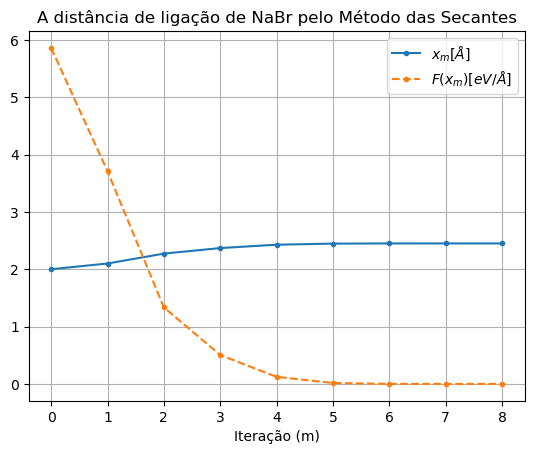

In [123]:
plt.plot(data['x_m'],'.-',label="$x_m [Å]$") #Plot das bisseções
plt.plot(data['f(x_m)'],'.--', label='$F(x_m) [eV/Å]$') #Plot da função em questão
#---------- Estética ----------
plt.legend()
plt.title("A distância de ligação de NaBr pelo Método das Secantes")
plt.xlabel("Iteração (m)")
plt.xticks(range(len(sol)))
plt.grid()

## Comentários Finais
- Tomei, em cada caso, $\epsilon = 10^{-6}$ porque me pareceu uma precisão razoável. Especialmente para o item (iii), já que o número de algarismos significativos de cada constante fornecida é 3.
- A escolha das regiões em cada plot foi feita para evidenciar o melhor possível os pontos de máximo/mínimo ou raízes
    - Na verdade, foi um processo meio recursivo: eu fiz o plot primeiro; gerei resultados; "refinei" a região de plot e gerei novos resultados. Acho que assim consegui manter uma apresentação mais agradável e didática para mim, caso queira futuramente voltar a esse material.
- A formatação da entrega pode estar meio esquisita, pois o EP inteiro foi elaborado no Jupyter Notebook. É um ambiente com o qual estou mais acostumado a trabalhar e acho que é o mais próximo que posso mandar de um arquivo em PDF com o código fonte explícito.
    - Eu até poderia escrever tudo isso em Latex, mas acho que derrotaria um pouco o propósito do corretor poder enxergar "a coisa funcionando".